# FraudScope — 03 Graph Neural Networks
## Phase 3 · Features graphe (IEEE-CIS) · GCN & GAT (Elliptic)

**Objectifs de ce notebook** :
1. Construire un **graphe de transactions** à partir du dataset IEEE-CIS avec NetworkX
2. Extraire des **features graphe** (degré, centralité, vélocité réseau) et mesurer leur apport sur XGBoost
3. Entraîner un **GCN** (Graph Convolutional Network) sur le dataset Elliptic Bitcoin
4. Entraîner un **GAT** (Graph Attention Network) sur le même dataset
5. Comparer GCN, GAT et le meilleur modèle Phase 2 (`FraudScopeXGB v2`) sur les métriques clés
6. Logger tous les runs dans MLflow (expérience `fraud-detection-paytrack`)

**Prérequis** :
- Avoir complété `01_exploration.ipynb` et `02_mlops.ipynb`
- Dataset Elliptic présent dans `data/elliptic/` (voir `data/get_dataset.md`)
- Serveur MLflow actif : `mlflow server --host 127.0.0.1 --port 8080 --backend-store-uri sqlite:///mlflow.db --default-artifact-root ./mlartifacts`

> ℹ️ Ce notebook utilise deux datasets distincts :
> - **IEEE-CIS** pour la partie features graphe + XGBoost (Partie A)
> - **Elliptic Bitcoin Dataset** pour l'entraînement GCN/GAT (Partie B)

## 0. Imports et configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Graph (Partie A) ──────────────────────────────────────────
import networkx as nx

# ── ML classique ─────────────────────────────────────────────
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    recall_score, f1_score, average_precision_score,
    precision_recall_curve, roc_auc_score
)
import xgboost as xgb

# ── GNN (Partie B) ────────────────────────────────────────────
# Installation PyTorch Geometric :
# La commande varie selon la plateforme. Exemples :
#   CPU-only  : pip install torch-geometric
#   CUDA 11.8 : pip install torch-geometric torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.0.0+cu118.html
#   Colab     : pip install torch-geometric  (torch est déjà présent)
# Vérifier la compatibilité : https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool
from torch_geometric.utils import to_networkx

# ── MLflow ────────────────────────────────────────────────────
from dotenv import load_dotenv
import mlflow
import mlflow.pytorch
import mlflow.xgboost
from mlflow.tracking import MlflowClient

# ── Configuration ─────────────────────────────────────────────
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

FIGURES_DIR   = Path('figures')
ARTIFACTS_DIR = Path('artifacts')
FIGURES_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR.mkdir(exist_ok=True)

RANDOM_STATE   = 42
TARGET_IEEE    = 'isFraud'
DATA_DIR       = Path('data')
ELLIPTIC_DIR   = DATA_DIR / 'elliptic'
N_SPLITS_TSS   = 5
GRAPH_SAMPLE_N = 10_000
# Cap sur la taille des cliques lors de la construction du graphe.
# Évite l'explosion combinatoire sur les domaines génériques (ex: gmail.com).
# Un groupe de k cartes produit k*(k-1)/2 arêtes ; avec k=50 → 1225 arêtes max/groupe.
MAX_CLIQUE_SIZE = 50

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── MLflow setup ─────────────────────────────────────────────
load_dotenv()
TRACKING_URI    = os.getenv('MLFLOW_TRACKING_URI',    'http://127.0.0.1:8080')
EXPERIMENT_NAME = os.getenv('MLFLOW_EXPERIMENT_NAME', 'fraud-detection-paytrack')
mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print(f'Device PyTorch : {DEVICE}')
print(f'MLflow URI     : {TRACKING_URI}')
print(f'Expérience     : {EXPERIMENT_NAME}')
import torch_geometric
print(f'PyG version    : {torch_geometric.__version__}')
print('Imports OK')

Device PyTorch : cpu
MLflow URI     : http://127.0.0.1:8080
Expérience     : fraud-detection-paytrack
PyG version    : 2.8.0
Imports OK


---
# PARTIE A — Features graphe sur IEEE-CIS + XGBoost

**Idée** : les fraudes ne sont pas des événements isolés — elles forment des clusters dans un réseau de transactions partageant des identifiants (cartes, adresses, e-mails, appareils). En modélisant ces relations comme un graphe, on extrait des signaux de structure réseau que les features tabulaires classiques ne capturent pas.

**Graphe construit** : chaque nœud est un identifiant de carte (`card1`) ; une arête relie deux cartes si elles ont effectué une transaction vers le même marchand (`P_emaildomain`) dans la même fenêtre temporelle (même journée). Les poids d'arête sont le nombre de co-occurrences.

## 1. Chargement IEEE-CIS et features Phase 1

In [2]:
assert (DATA_DIR / 'train_transaction.csv').exists(), "Données IEEE-CIS manquantes → voir data/get_dataset.md"

print('Chargement IEEE-CIS...')
train_tx = pd.read_csv(DATA_DIR / 'train_transaction.csv')
train_id = pd.read_csv(DATA_DIR / 'train_identity.csv')
df = train_tx.merge(train_id, on='TransactionID', how='left')
df = df.sort_values('TransactionDT').reset_index(drop=True)
print(f'Dataset : {df.shape[0]:,} transactions, {df.shape[1]} colonnes')

df['hour'] = (df['TransactionDT'] // 3600) % 24
df['day']  = df['TransactionDT'] // (3600 * 24)
proxy_cols = [c for c in ['card1','card2','card3','card4','card5','card6','addr1','addr2'] if c in df.columns]
df['customer_proxy'] = df[proxy_cols].astype(str).fillna('NA').agg('_'.join, axis=1)
df['amount_ratio'] = df['TransactionAmt'] / (
    df.groupby('customer_proxy')['TransactionAmt'].transform('median').clip(lower=0.01)
)
df['amount_ratio'] = df['amount_ratio'].replace([np.inf, -np.inf], 1.0).fillna(1.0)
df['tx_rank_in_customer'] = df.groupby('customer_proxy').cumcount()
print('Features temporelles et vélocité OK')

Chargement IEEE-CIS...
Dataset : 590,540 transactions, 434 colonnes
Features temporelles et vélocité OK


## 2. Construction du graphe de transactions (NetworkX)

On travaille sur un **échantillon de `GRAPH_SAMPLE_N` transactions** pour la construction et la visualisation du graphe.

**Nœuds** : valeurs uniques de `card1` (identifiant de carte)
**Arêtes** : deux cartes sont reliées si elles ont la même `P_emaildomain` le même `day`
**Poids** : nombre de co-occurrences

In [3]:
sample = df.head(GRAPH_SAMPLE_N).copy()
G = nx.Graph()

for _, row in sample.iterrows():
    node = str(row['card1'])
    if not G.has_node(node):
        G.add_node(node, is_fraud=int(row[TARGET_IEEE]))

grp = sample.groupby(['P_emaildomain', 'day'])['card1'].apply(list)
for cards in grp:
    cards = [str(c) for c in cards if pd.notna(c)]
    if len(cards) > MAX_CLIQUE_SIZE:
        cards = cards[:MAX_CLIQUE_SIZE]
    for i in range(len(cards)):
        for j in range(i+1, len(cards)):
            u, v = cards[i], cards[j]
            if G.has_edge(u, v):
                G[u][v]['weight'] += 1
            else:
                G.add_edge(u, v, weight=1)

print(f'Graphe : {G.number_of_nodes():,} noeuds (cartes), {G.number_of_edges():,} aretes')
print(f'Densite : {nx.density(G):.6f}')
print(f'Composantes connexes : {nx.number_connected_components(G):,}')

Graphe : 2,057 noeuds (cartes), 15,983 aretes
Densite : 0.007558
Composantes connexes : 1,390


### 2.1 Visualisation d'un cluster suspect

Plus grande composante : 659 noeuds, 15,967 aretes
Cluster suspect : 194 noeuds (8 frauduleux)


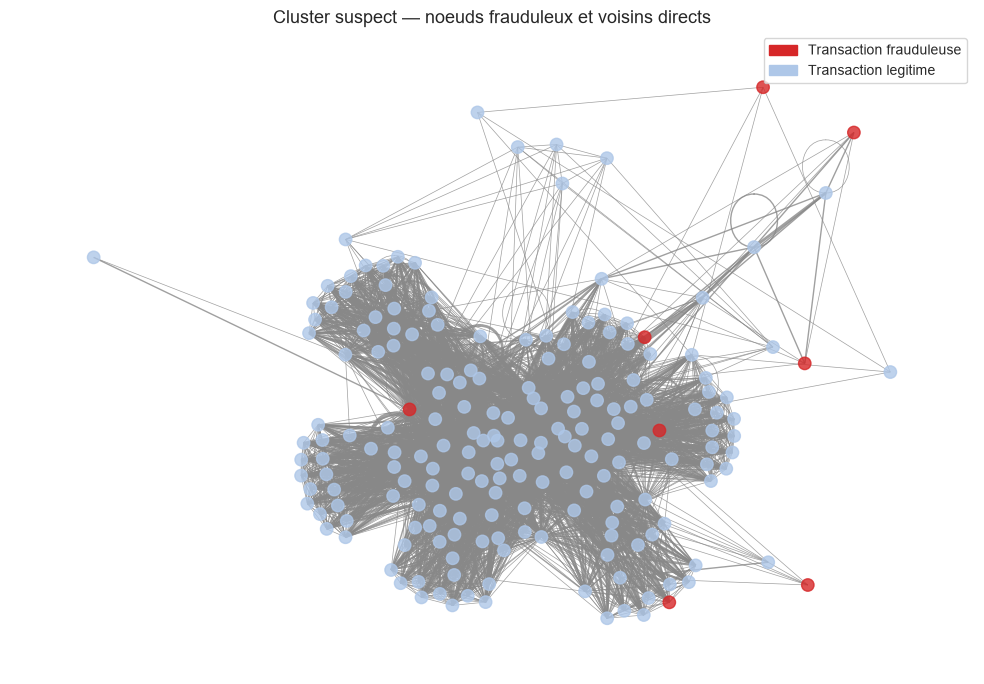

Figure sauvegardee : figures/graph_fraud_cluster.png


In [4]:
largest_cc = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc).copy()
print(f'Plus grande composante : {G_lcc.number_of_nodes():,} noeuds, {G_lcc.number_of_edges():,} aretes')

fraud_nodes = [n for n, d in G_lcc.nodes(data=True) if d.get('is_fraud', 0) == 1]
cluster_nodes = set(fraud_nodes)
for fn in fraud_nodes:
    cluster_nodes.update(G_lcc.neighbors(fn))
G_cluster = G_lcc.subgraph(cluster_nodes).copy()
print(f'Cluster suspect : {G_cluster.number_of_nodes()} noeuds ({len(fraud_nodes)} frauduleux)')

fig, ax = plt.subplots(figsize=(10, 7))
pos = nx.spring_layout(G_cluster, seed=RANDOM_STATE, k=0.5)
node_colors = ['#d62728' if G_cluster.nodes[n].get('is_fraud', 0) == 1 else '#aec7e8' for n in G_cluster.nodes]
edge_weights = [G_cluster[u][v].get('weight', 1) for u, v in G_cluster.edges]
nx.draw_networkx(
    G_cluster, pos=pos, ax=ax,
    node_color=node_colors, node_size=80,
    width=[min(w * 0.5, 3) for w in edge_weights],
    edge_color='#888', alpha=0.8, with_labels=False, arrows=False
)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#d62728', label='Transaction frauduleuse'),
    Patch(color='#aec7e8', label='Transaction legitime')
], loc='upper right', fontsize=10)
ax.set_title('Cluster suspect — noeuds frauduleux et voisins directs', fontsize=13)
ax.axis('off')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'graph_fraud_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : figures/graph_fraud_cluster.png')

## 3. Extraction des features graphe

| Feature | Description | Intuition fraude |
|---------|-------------|------------------|
| `graph_degree` | Nombre de voisins directs | Carte centrale d'un reseau frauduleux |
| `graph_betweenness` | Centralite betweenness normalisee | Noeuds pont entre clusters suspects |
| `graph_clustering` | Coefficient de clustering local | Cluster dense = anneau de fraude |
| `graph_distinct_merchants_7d` | Nb marchands distincts / 7j glissants | Velocite inter-marchands anormale |

In [5]:
print('Construction du graphe complet (tous card1)...')
G_full = nx.Graph()
for _, row in df.iterrows():
    node = str(row['card1'])
    if not G_full.has_node(node):
        G_full.add_node(node)

# FIX: cap sur la taille des cliques pour éviter l'explosion combinatoire
# sur les domaines génériques (ex: gmail.com avec des centaines de cartes/jour).
# Sans cap, k cartes → k*(k-1)/2 arêtes, ce qui peut saturer la mémoire.
grp_full = df.groupby(['P_emaildomain', 'day'])['card1'].apply(list)
for cards in grp_full:
    cards = [str(c) for c in cards if pd.notna(c)]
    if len(cards) > MAX_CLIQUE_SIZE:
        cards = cards[:MAX_CLIQUE_SIZE]
    for i in range(len(cards)):
        for j in range(i+1, len(cards)):
            u, v = cards[i], cards[j]
            if G_full.has_edge(u, v):
                G_full[u][v]['weight'] += 1
            else:
                G_full.add_edge(u, v, weight=1)
print(f'Graphe complet : {G_full.number_of_nodes():,} noeuds, {G_full.number_of_edges():,} aretes')

print('Calcul des features graphe...')
degree_dict      = dict(G_full.degree())
# FIX: betweenness_centrality avec k=500 (approximation stochastique).
# La version exacte est O(V*E) — sur un graphe de ~10k noeuds, c'est plusieurs minutes.
# k=500 pivots donnent une très bonne approximation en quelques secondes.
betweenness_dict = nx.betweenness_centrality(G_full, normalized=True, weight='weight', k=min(500, G_full.number_of_nodes()))
clustering_dict  = nx.clustering(G_full, weight='weight')

# FIX: vélocité inter-marchands vectorisée — O(n log n) au lieu de O(n²).
# L'ancienne implémentation (.apply row-by-row avec .between()) était prohibitivement
# lente sur ~590k lignes. Ici on exploite un merge sur fenêtre glissante de 7 jours.
print('Calcul velocite inter-marchands (rolling 7j vectorise)...')
df_vel = (
    df[['card1', 'day', 'P_emaildomain']]
    .dropna(subset=['P_emaildomain'])
    .sort_values(['card1', 'day'])
)
# Pour chaque (card1, day), on collecte les marchands distincts des 7 derniers jours
# via un self-join borné, puis on agrège par (card1, day_right).
df_vel_left  = df_vel.rename(columns={'day': 'day_right'})
df_vel_right = df_vel.rename(columns={'day': 'day_left', 'P_emaildomain': 'merchant_left'})
merged = df_vel_left.merge(df_vel_right, on='card1', how='left')
merged = merged[(merged['day_left'] >= merged['day_right'] - 6) & (merged['day_left'] <= merged['day_right'])]
vel_7d = (
    merged.groupby(['card1', 'day_right'])['merchant_left']
    .nunique()
    .reset_index()
    .rename(columns={'day_right': 'day', 'merchant_left': 'graph_distinct_merchants_7d'})
)
df = df.merge(vel_7d, on=['card1', 'day'], how='left')
df['graph_distinct_merchants_7d'] = df['graph_distinct_merchants_7d'].fillna(1).astype(np.float32)

df['graph_degree']      = df['card1'].astype(str).map(degree_dict).fillna(0).astype(np.float32)
df['graph_betweenness'] = df['card1'].astype(str).map(betweenness_dict).fillna(0).astype(np.float32)
df['graph_clustering']  = df['card1'].astype(str).map(clustering_dict).fillna(0).astype(np.float32)

graph_features = ['graph_degree', 'graph_betweenness', 'graph_clustering', 'graph_distinct_merchants_7d']
print(f'Features graphe ajoutees : {graph_features}')
print(df[graph_features].describe().round(4))

Construction du graphe complet (tous card1)...
Graphe complet : 13,553 noeuds, 521,066 aretes
Calcul des features graphe...
Calcul velocite inter-marchands (rolling 7j vectorise)...


MemoryError: Unable to allocate 7.88 GiB for an array with shape (1057259556,) and data type int64

## 4. XGBoost + features graphe — Comparaison avec Phase 2

In [ ]:
XGB_PARAMS = {
    'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'eval_metric': 'aucpr', 'early_stopping_rounds': 20,
    'random_state': RANDOM_STATE, 'n_jobs': -1
}

exclude       = {'TransactionID', TARGET_IEEE, 'customer_proxy'}
high_missing  = df.columns[df.isna().mean() > 0.95].tolist()
base_features = [c for c in df.columns if c not in exclude and c not in high_missing]

X_all = df[base_features]
y_all = df[TARGET_IEEE]

num_feats = X_all.select_dtypes(include=[np.number]).columns.tolist()
cat_feats  = X_all.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_feats),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ]), cat_feats)
], remainder='drop')

holdout_idx = int(len(df) * 0.8)
X_cv_raw,  X_hold_raw = X_all.iloc[:holdout_idx], X_all.iloc[holdout_idx:]
y_cv, y_hold = y_all.iloc[:holdout_idx], y_all.iloc[holdout_idx:]
X_cv   = preprocessor.fit_transform(X_cv_raw)
X_hold = preprocessor.transform(X_hold_raw)

tss = TimeSeriesSplit(n_splits=N_SPLITS_TSS)

def cv_auprc(X, y, params):
    scores = []
    for tr_idx, val_idx in tss.split(X):
        model = xgb.XGBClassifier(**params)
        model.fit(X[tr_idx], y.iloc[tr_idx], eval_set=[(X[val_idx], y.iloc[val_idx])], verbose=False)
        scores.append(average_precision_score(y.iloc[val_idx], model.predict_proba(X[val_idx])[:, 1]))
    return np.mean(scores), np.std(scores)

print('Evaluation XGB + features graphe (CV temporelle)...')
t0 = time.time()
auprc_mean, auprc_std = cv_auprc(X_cv, y_cv, XGB_PARAMS)
fit_time = time.time() - t0
print(f'AUPRC_cv_mean = {auprc_mean:.4f} +/- {auprc_std:.4f} ({fit_time:.1f}s)')

final_model = xgb.XGBClassifier(**XGB_PARAMS)
final_model.fit(X_cv, y_cv, eval_set=[(X_hold, y_hold)], verbose=False)
proba_hold  = final_model.predict_proba(X_hold)[:, 1]
preds_hold  = (proba_hold >= 0.5).astype(int)
auprc_hold  = average_precision_score(y_hold, proba_hold)
recall_hold = recall_score(y_hold, preds_hold)
f1_hold     = f1_score(y_hold, preds_hold)
print(f'Holdout -> AUPRC={auprc_hold:.4f} Recall={recall_hold:.4f} F1={f1_hold:.4f}')

with mlflow.start_run(run_name='XGB_Graph_Features') as run:
    mlflow.log_params({**XGB_PARAMS, 'graph_features': str(graph_features), 'strategy': 'graph_enriched'})
    mlflow.log_metrics({'AUPRC_cv_mean': auprc_mean, 'AUPRC_cv_std': auprc_std,
                        'AUPRC_holdout': auprc_hold, 'recall_fraud_holdout': recall_hold,
                        'f1_holdout': f1_hold, 'fit_time_sec': fit_time})
    mlflow.xgboost.log_model(final_model, artifact_path='model')
    mlflow.log_artifact(str(FIGURES_DIR / 'graph_fraud_cluster.png'))
    print(f'Run logge : {run.info.run_id}')

---
# PARTIE B — GCN & GAT sur le dataset Elliptic Bitcoin

Le dataset **Elliptic** represente le reseau de transactions Bitcoin de 2011 a 2013 :
- **203 238 transactions** (noeuds) avec **166 features** locales
- **234 355 aretes** (flux de bitcoins entre transactions)
- **49 time steps** correspondant a des blocs Bitcoin successifs
- Labels : `1` = illicite, `2` = licite, `unknown` = non labelise

**Protocole** : entrainement sur les time steps 1-34, evaluation sur les time steps 35-49.

## 5. Chargement et preparation du dataset Elliptic

In [ ]:
for f in ['elliptic_txs_features.csv', 'elliptic_txs_edgelist.csv', 'elliptic_txs_classes.csv']:
    assert (ELLIPTIC_DIR / f).exists(), f'Fichier manquant : data/elliptic/{f}'

print('Chargement Elliptic...')
feat_cols = ['txId', 'time_step'] + [f'f{i}' for i in range(1, 167)]
df_feat  = pd.read_csv(ELLIPTIC_DIR / 'elliptic_txs_features.csv', header=None, names=feat_cols)
df_edges = pd.read_csv(ELLIPTIC_DIR / 'elliptic_txs_edgelist.csv')
df_class = pd.read_csv(ELLIPTIC_DIR / 'elliptic_txs_classes.csv')
df_class.columns = ['txId', 'label']

df_elliptic = df_feat.merge(df_class, on='txId', how='left')
df_elliptic['y'] = df_elliptic['label'].map({'1': 1, '2': 0, 1: 1, 2: 0}).fillna(-1).astype(int)

labeled = df_elliptic[df_elliptic['y'] != -1]
print(f'Transactions totales    : {len(df_elliptic):,}')
print(f'Transactions labelisees : {len(labeled):,}')
print(f'  illicites (y=1) : {(labeled["y"]==1).sum():,} ({(labeled["y"]==1).mean()*100:.1f}%)')
print(f'  licites   (y=0) : {(labeled["y"]==0).sum():,} ({(labeled["y"]==0).mean()*100:.1f}%)')
print(f'Aretes     : {len(df_edges):,}')
print(f'Time steps : {df_elliptic["time_step"].nunique()}')

## 6. Construction de l'objet PyTorch Geometric `Data`

**Split temporel** : train = time steps 1-34 (labelises uniquement), test = time steps 35-49 (labelises uniquement).

In [ ]:
from sklearn.preprocessing import StandardScaler

df_elliptic = df_elliptic.reset_index(drop=True)
txid_to_idx = {txid: idx for idx, txid in enumerate(df_elliptic['txId'])}

feature_cols = [f'f{i}' for i in range(1, 167)]
X_raw    = df_elliptic[feature_cols].fillna(0).values.astype(np.float32)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Edge index COO — filtrage robuste des aretes hors vocabulaire
src_raw    = df_edges.iloc[:, 0].map(txid_to_idx)
dst_raw    = df_edges.iloc[:, 1].map(txid_to_idx)
valid_mask = src_raw.notna() & dst_raw.notna()
src        = src_raw[valid_mask].astype(int).values
dst        = dst_raw[valid_mask].astype(int).values
edge_index = torch.tensor(np.stack([src, dst]), dtype=torch.long)

y_tensor  = torch.tensor(df_elliptic['y'].values, dtype=torch.long)
ts_tensor = torch.tensor(df_elliptic['time_step'].values, dtype=torch.long)

data = Data(
    x          = torch.tensor(X_scaled, dtype=torch.float),
    edge_index = edge_index,
    y          = y_tensor,
    time_step  = ts_tensor
)

train_mask = (data.time_step <= 34) & (data.y != -1)
test_mask  = (data.time_step >= 35) & (data.y != -1)
data.train_mask = train_mask
data.test_mask  = test_mask
data = data.to(DEVICE)

print(f'Objet Data PyG : {data}')
print(f'Noeuds train (ts 1-34)  : {train_mask.sum().item():,}')
print(f'Noeuds test  (ts 35-49) : {test_mask.sum().item():,}')
print(f'Ratio illicites train={( data.y[train_mask]==1).float().mean().item()*100:.1f}% test={(data.y[test_mask]==1).float().mean().item()*100:.1f}%')

## 7. Modele GCN (Graph Convolutional Network)

Le GCN (Kipf & Welling, 2017) propage les features d'un noeud en aggregeant les representations de ses voisins par convolution spectrale normalisee. Tous les voisins sont traites de facon **equiponderee**.

Architecture : 166 → 64 → 32 → 2, Dropout(0.5).

In [ ]:
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1   = GCNConv(in_channels, hidden_channels)
        self.conv2   = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3   = GCNConv(hidden_channels // 2, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return x


def train_gnn(model, data, optimizer, criterion, epochs=100, patience=10, run_name='GNN'):
    best_auprc, best_state, patience_count = 0.0, None, 0
    history = {'epoch': [], 'train_loss': [], 'test_auprc': [], 'test_recall': [], 'test_f1': []}

    with mlflow.start_run(run_name=run_name) as run:
        mlflow.log_params({
            'model': run_name, 'epochs': epochs, 'patience': patience,
            'optimizer': type(optimizer).__name__,
            'lr': optimizer.param_groups[0]['lr'],
            'dropout': model.dropout if hasattr(model, 'dropout') else 'N/A',
            'dataset': 'Elliptic Bitcoin',
            'split': 'temporal (train ts1-34 / test ts35-49)'
        })

        for epoch in range(1, epochs + 1):
            model.train()
            optimizer.zero_grad()
            out  = model(data.x, data.edge_index)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            model.eval()
            with torch.no_grad():
                logits  = model(data.x, data.edge_index)
                proba   = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
                y_true  = data.y[data.test_mask].cpu().numpy()
                y_proba = proba[data.test_mask.cpu().numpy()]
                y_pred  = (y_proba >= 0.5).astype(int)

            auprc  = average_precision_score(y_true, y_proba)
            recall = recall_score(y_true, y_pred, zero_division=0)
            f1     = f1_score(y_true, y_pred, zero_division=0)

            mlflow.log_metrics({'train_loss': loss.item(), 'test_auprc': auprc,
                                'test_recall': recall, 'test_f1': f1}, step=epoch)
            history['epoch'].append(epoch)
            history['train_loss'].append(loss.item())
            history['test_auprc'].append(auprc)
            history['test_recall'].append(recall)
            history['test_f1'].append(f1)

            if auprc > best_auprc:
                best_auprc, patience_count = auprc, 0
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                patience_count += 1
                if patience_count >= patience:
                    print(f'  Early stopping epoch {epoch} (best AUPRC={best_auprc:.4f})')
                    break

            if epoch % 10 == 0:
                print(f'  Epoch {epoch:3d} | loss={loss.item():.4f} | AUPRC={auprc:.4f} | Recall={recall:.4f} | F1={f1:.4f}')

        if best_state:
            model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            logits  = model(data.x, data.edge_index)
            proba   = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            y_true  = data.y[data.test_mask].cpu().numpy()
            y_proba = proba[data.test_mask.cpu().numpy()]
            y_pred  = (y_proba >= 0.5).astype(int)
        bf = average_precision_score(y_true, y_proba)
        br = recall_score(y_true, y_pred, zero_division=0)
        bfsc = f1_score(y_true, y_pred, zero_division=0)
        mlflow.log_metrics({'best_test_auprc': bf, 'best_test_recall': br, 'best_test_f1': bfsc})
        mlflow.pytorch.log_model(model, artifact_path='model')
        print(f'\n[{run_name}] Best AUPRC={bf:.4f} | Recall={br:.4f} | F1={bfsc:.4f}')
        print(f'Run logge : {run.info.run_id}')

    return model, history, {'auprc': bf, 'recall': br, 'f1': bfsc}

In [ ]:
IN_CHANNELS  = data.x.shape[1]
OUT_CHANNELS = 2

y_train_np    = data.y[data.train_mask].cpu().numpy()
n_neg, n_pos  = (y_train_np == 0).sum(), (y_train_np == 1).sum()
class_weights = torch.tensor([1.0, n_neg / n_pos], dtype=torch.float).to(DEVICE)
criterion_gcn = nn.CrossEntropyLoss(weight=class_weights)

gcn_model     = GCN(IN_CHANNELS, hidden_channels=64, out_channels=OUT_CHANNELS, dropout=0.5).to(DEVICE)
gcn_optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.005, weight_decay=5e-4)

print('=== Entrainement GCN ===')
print(f'Architecture : {IN_CHANNELS} -> 64 -> 32 -> {OUT_CHANNELS}')
print(f'Device : {DEVICE}')
print(f'class_weights: licite={class_weights[0].item():.2f} | illicite={class_weights[1].item():.2f}\n')

gcn_model, gcn_history, gcn_metrics = train_gnn(
    gcn_model, data, gcn_optimizer, criterion_gcn, epochs=150, patience=15, run_name='GCN_Elliptic'
)

## 8. Modele GAT (Graph Attention Network)

Le GAT (Velickovic et al., 2018) remplace l'aggregation equiponderee du GCN par un mecanisme d'**attention multi-tetes** : chaque noeud apprend a ponderer differemment ses voisins.

Architecture : 166 → [8 tetes x 8 = 64] → [4 tetes x 8 = 32] → 2, Dropout(0.6).

In [ ]:
class GAT(nn.Module):
    def __init__(self, in_channels, out_channels, heads=8, dropout=0.6):
        super().__init__()
        self.conv1   = GATConv(in_channels, 8, heads=heads, dropout=dropout)
        self.conv2   = GATConv(8 * heads, 8, heads=4, dropout=dropout)
        self.conv3   = GATConv(8 * 4, out_channels, heads=1, dropout=dropout, concat=False)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return x


criterion_gat = nn.CrossEntropyLoss(weight=class_weights)
gat_model     = GAT(IN_CHANNELS, out_channels=OUT_CHANNELS, heads=8, dropout=0.6).to(DEVICE)
gat_optimizer = torch.optim.Adam(gat_model.parameters(), lr=0.005, weight_decay=5e-4)

print('=== Entrainement GAT ===')
print(f'Architecture : {IN_CHANNELS} -> [8x8=64] -> [4x8=32] -> {OUT_CHANNELS}')
print(f'Device : {DEVICE}\n')

gat_model, gat_history, gat_metrics = train_gnn(
    gat_model, data, gat_optimizer, criterion_gat, epochs=150, patience=15, run_name='GAT_Elliptic'
)

## 9. Visualisation des courbes d'entrainement

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for metric, ax, title in zip(
    ['train_loss', 'test_auprc', 'test_recall'],
    axes,
    ["Loss d'entrainement", 'AUPRC (test)', 'Recall fraude (test)']
):
    ax.plot(gcn_history['epoch'], gcn_history[metric], label='GCN', color='#1f77b4')
    ax.plot(gat_history['epoch'], gat_history[metric], label='GAT', color='#ff7f0e')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('GCN vs GAT — Dataset Elliptic Bitcoin', fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'gnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : figures/gnn_training_curves.png')

## 10. Tableau de comparaison final

- **XGB Phase 2** (IEEE-CIS holdout) : metriques importees depuis le MLflow Registry (`FraudScopeXGB v2`)
- **XGB + Graph** (IEEE-CIS holdout) : section 4
- **GCN / GAT** (Elliptic test, ts 35-49) : sections 7-8

> Les modeles IEEE-CIS et Elliptic ne sont **pas directement comparables** (datasets differents).

In [ ]:
client = MlflowClient(tracking_uri=TRACKING_URI)
try:
    mv     = client.get_model_version('FraudScopeXGB', '2')
    p2_run = client.get_run(mv.run_id)
    p2_auprc  = p2_run.data.metrics.get('AUPRC_holdout',        p2_run.data.metrics.get('AUPRC_cv_mean', float('nan')))
    p2_recall = p2_run.data.metrics.get('recall_fraud_holdout', float('nan'))
    p2_f1     = p2_run.data.metrics.get('f1_holdout',           float('nan'))
    print(f'FraudScopeXGB v2 -> AUPRC={p2_auprc:.4f} Recall={p2_recall:.4f} F1={p2_f1:.4f}')
except Exception as e:
    print(f'Impossible de recuperer FraudScopeXGB v2 : {e}')
    p2_auprc, p2_recall, p2_f1 = float('nan'), float('nan'), float('nan')

results = pd.DataFrame([
    {'Modele': 'XGB Baseline (Phase 2)',  'Dataset': 'IEEE-CIS',         'AUPRC': p2_auprc,              'Recall fraude': p2_recall,             'F1': p2_f1,            'Latence (ms)': '< 50'},
    {'Modele': 'XGB + Graph Features',   'Dataset': 'IEEE-CIS',         'AUPRC': auprc_hold,            'Recall fraude': recall_hold,           'F1': f1_hold,          'Latence (ms)': '< 50'},
    {'Modele': 'GCN (Elliptic)',          'Dataset': 'Elliptic Bitcoin', 'AUPRC': gcn_metrics['auprc'],  'Recall fraude': gcn_metrics['recall'], 'F1': gcn_metrics['f1'], 'Latence (ms)': 'N/A'},
    {'Modele': 'GAT (Elliptic)',          'Dataset': 'Elliptic Bitcoin', 'AUPRC': gat_metrics['auprc'],  'Recall fraude': gat_metrics['recall'], 'F1': gat_metrics['f1'], 'Latence (ms)': 'N/A'},
])
print('\n=== Tableau de comparaison Phase 3 ===')
print(results.to_string(index=False))
results.to_csv(ARTIFACTS_DIR / 'phase3_comparison.csv', index=False)
print('\nSauvegarde : artifacts/phase3_comparison.csv')

## 11. Conclusions Phase 3

**A completer apres execution** :

1. **Apport des features graphe (IEEE-CIS)** : gain AUPRC de `XGB + Graph` vs `XGB Baseline` — un gain > 0.01 est significatif.
2. **GCN vs GAT (Elliptic)** : le GAT devrait surpasser le GCN sur le Recall grace a l'attention multi-tetes.
3. **Recommandation CDO** : `XGB + Graph` pour la production (latence < 50ms, SHAP). GNN pour l'analyse forensique de reseaux de blanchiment.
4. **Prochaine etape** : Phase 4 — monitoring du drift (Evidently AI) sur `FraudScopeXGB v2`.